In [1]:
# ─────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────
 
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# ─────────────────────────────────────────────
# 1. CONFIGURATION
# ─────────────────────────────────────────────
 
DATASET_ROOT = "C:/Users/kavin/Downloads/FreshHarvest_Dataset/FRUIT-16K"
SPLITS_FILE  = "freshharvest_splits.pt"
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
NUM_WORKERS  = 0           # Must be 0 on Windows
RANDOM_SEED  = 42
 
# ── Transfer Learning settings ─────────────────────────────────
#
#  Two-phase fine-tuning strategy:
#
#  Phase 1 — Feature Extraction (freeze all ResNet50 layers)
#             Only the new FC head is trained.
#             Fast convergence, low compute.
#
#  Phase 2 — Fine-tuning (unfreeze last ResNet50 block: layer4)
#             Deeper layers adapt to fruit images.
#             Lower LR to avoid destroying pretrained weights.
#
PHASE1_EPOCHS = 5       # Feature extraction (frozen backbone)
PHASE2_EPOCHS = 5       # Fine-tuning (unfrozen layer4)
PHASE1_LR     = 0.001   # Higher LR — only FC head trains
PHASE2_LR     = 0.0001  # Lower LR — fine-tuning deeper layers
 
# ── Early stopping ─────────────────────────────────────────────
EARLY_STOP_PATIENCE = 4
 
BINARY_NAMES = ["Fresh", "Spoiled"]
BINARY_LABEL = {"F": 0, "S": 1}
FRUIT_NAMES  = [
    "Banana", "Lemon", "Lulo", "Mango",
    "Orange", "Strawberry", "Tamarillo", "Tomato"
]
 
# ── Device ─────────────────────────────────────────────────────
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"
print(f"✅ Device : {device}")
if device.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
 
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)

✅ Device : cuda
   GPU    : NVIDIA GeForce GTX 1650
   VRAM   : 4.0 GB


In [3]:
# 2. TRANSFORMS
# ─────────────────────────────────────────────
#
#  ResNet50 was pretrained on ImageNet with 224×224 images
#  normalized using ImageNet mean & std — we keep the same.
# ─────────────────────────────────────────────
 
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
 
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
val_test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
print("\n✅ Transforms defined.")


✅ Transforms defined.


In [4]:
# 3. DATASET & DATALOADERS
# ─────────────────────────────────────────────
 
class FreshHarvestDataset(Dataset):
    """Reads FRUIT_16K: F_<Fruit>→Fresh(0) | S_<Fruit>→Spoiled(1)"""
    def __init__(self, root, transform=None):
        self.root      = Path(root)
        self.transform = transform
        self.samples   = []
        for folder in sorted(self.root.iterdir()):
            if not folder.is_dir():
                continue
            parts = folder.name.split("_", 1)
            if len(parts) != 2 or parts[0] not in BINARY_LABEL:
                continue
            label = BINARY_LABEL[parts[0]]
            for img_file in sorted(folder.iterdir()):
                if img_file.suffix.lower() in {".jpg", ".jpeg", ".png",
                                               ".bmp", ".webp"}:
                    self.samples.append(
                        (str(img_file), label, parts[1], folder.name))
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        img_path, label, _, _ = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label
 
    @property
    def labels(self):
        return [s[1] for s in self.samples]
 
 
class TransformSubset(Dataset):
    def __init__(self, base, indices, transform):
        self.base      = base
        self.indices   = indices
        self.transform = transform
 
    def __len__(self):
        return len(self.indices)
 
    def __getitem__(self, idx):
        img_path, label, _, _ = self.base.samples[self.indices[idx]]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label
 
 
# ── Load splits from Week 1 ────────────────────────────────────
print(f"\n✅ Loading splits from: {SPLITS_FILE}")
splits      = torch.load(SPLITS_FILE, weights_only=False)
train_idx   = splits["train_idx"]
val_idx     = splits["val_idx"]
test_idx    = splits["test_idx"]
 
base_dataset  = FreshHarvestDataset(root=DATASET_ROOT, transform=None)
train_dataset = TransformSubset(base_dataset, train_idx, train_transforms)
val_dataset   = TransformSubset(base_dataset, val_idx,   val_test_transforms)
test_dataset  = TransformSubset(base_dataset, test_idx,  val_test_transforms)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)
 
print(f"   Train  : {len(train_dataset):,} images → {len(train_loader)} batches")
print(f"   Val    : {len(val_dataset):,}  images → {len(val_loader)} batches")
print(f"   Test   : {len(test_dataset):,}  images → {len(test_loader)} batches")


✅ Loading splits from: freshharvest_splits.pt
   Train  : 11,200 images → 350 batches
   Val    : 2,400  images → 75 batches
   Test   : 2,400  images → 75 batches


In [5]:
# ─────────────────────────────────────────────
# 4. MODEL — ResNet50 with custom FC head
# ─────────────────────────────────────────────
#
#  ResNet50 architecture:
#    conv1 → bn1 → relu → maxpool
#    → layer1 (3 blocks)
#    → layer2 (4 blocks)
#    → layer3 (6 blocks)
#    → layer4 (3 blocks)   ← we unfreeze this in Phase 2
#    → avgpool
#    → fc (2048 → 1000)    ← we REPLACE this with our head
#
#  Our custom head:
#    fc (2048 → 256) → ReLU → Dropout(0.4) → fc (256 → 2)
# ─────────────────────────────────────────────
 
def build_resnet50(num_classes=2):
    """
    Load pretrained ResNet50 and replace the final FC layer
    with a custom classification head for Fresh/Spoiled.
    """
    # Load pretrained weights (ImageNet)
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
 
    # ── Freeze ALL backbone layers initially (Phase 1) ─────────
    for param in model.parameters():
        param.requires_grad = False
 
    # ── Replace the FC head with our custom classifier ─────────
    in_features = model.fc.in_features   # 2048 for ResNet50
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(256, num_classes),
    )
    # Note: only model.fc params have requires_grad=True now
 
    return model
 
 
model = build_resnet50(num_classes=2).to(device)
 
# Count trainable vs frozen params
total_params     = sum(p.numel() for p in model.parameters())
trainable_phase1 = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)
print(f"\n✅ ResNet50 loaded with custom FC head.")
print(f"   Total parameters       : {total_params:,}")
print(f"   Trainable (Phase 1)    : {trainable_phase1:,}  (FC head only)")
print(f"   Frozen (Phase 1)       : {total_params - trainable_phase1:,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\kavin/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:20<00:00, 4.93MB/s]



✅ ResNet50 loaded with custom FC head.
   Total parameters       : 24,033,090
   Trainable (Phase 1)    : 525,058  (FC head only)
   Frozen (Phase 1)       : 23,508,032


In [6]:
# ─────────────────────────────────────────────
# 5. TRAIN & EVAL HELPERS
# ─────────────────────────────────────────────
 
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total * 100
 
 
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total * 100, all_preds, all_labels
 
 
def run_phase(model, loader_tr, loader_val, criterion, optimizer,
              num_epochs, phase_name, patience, device):
    """Generic training loop with early stopping for one phase."""
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
    }
    best_val_acc    = 0.0
    best_model_wts  = None
    patience_counter = 0
    stopped_at      = num_epochs
 
    print(f"\n  {'─'*56}")
    print(f"  {phase_name}")
    print(f"  {'─'*56}")
 
    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc        = train_one_epoch(
            model, loader_tr, criterion, optimizer, device)
        vl_loss, vl_acc, _, _ = evaluate(
            model, loader_val, criterion, device)
 
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
 
        improved = vl_acc > best_val_acc
        if improved:
            best_val_acc    = vl_acc
            best_model_wts  = {k: v.clone()
                               for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
 
        tag = " ⭐" if improved else \
              f" (patience {patience_counter}/{patience})"
        print(f"  Epoch [{epoch:>2}/{num_epochs}] "
              f"│ Train {tr_acc:.2f}%  Loss {tr_loss:.4f} "
              f"│ Val {vl_acc:.2f}%  Loss {vl_loss:.4f}{tag}")
 
        if patience_counter >= patience:
            stopped_at = epoch
            print(f"\n  ⏹  Early stopping at epoch {epoch}")
            break
 
    model.load_state_dict(best_model_wts)
    return model, history, best_val_acc, stopped_at

In [7]:
# ─────────────────────────────────────────────
# 6. PHASE 1 — Feature Extraction
#    (Backbone frozen, only FC head trains)
# ─────────────────────────────────────────────
 
print(f"\n{'='*60}")
print(f"  🚀 PHASE 1 — Feature Extraction")
print(f"     Backbone : FROZEN  |  FC head : TRAINABLE")
print(f"     Epochs   : {PHASE1_EPOCHS}  |  LR : {PHASE1_LR}")
print(f"{'='*60}")
 
criterion   = nn.CrossEntropyLoss()
optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR
)
 
model, history_p1, best_val_p1, stopped_p1 = run_phase(
    model, train_loader, val_loader,
    criterion, optimizer_p1,
    PHASE1_EPOCHS, "Phase 1 – Feature Extraction",
    EARLY_STOP_PATIENCE, device
)
 
print(f"\n  ✅ Phase 1 Best Val Acc : {best_val_p1:.2f}%")


  🚀 PHASE 1 — Feature Extraction
     Backbone : FROZEN  |  FC head : TRAINABLE
     Epochs   : 5  |  LR : 0.001

  ────────────────────────────────────────────────────────
  Phase 1 – Feature Extraction
  ────────────────────────────────────────────────────────
  Epoch [ 1/5] │ Train 90.61%  Loss 0.2261 │ Val 95.62%  Loss 0.1140 ⭐
  Epoch [ 2/5] │ Train 95.00%  Loss 0.1297 │ Val 97.04%  Loss 0.0842 ⭐
  Epoch [ 3/5] │ Train 95.96%  Loss 0.1075 │ Val 97.50%  Loss 0.0660 ⭐
  Epoch [ 4/5] │ Train 96.54%  Loss 0.0964 │ Val 95.96%  Loss 0.0976 (patience 1/4)
  Epoch [ 5/5] │ Train 96.71%  Loss 0.0879 │ Val 97.96%  Loss 0.0575 ⭐

  ✅ Phase 1 Best Val Acc : 97.96%


In [8]:
# ─────────────────────────────────────────────
# 7. PHASE 2 — Fine-tuning
#    (Unfreeze layer4 of ResNet50 + FC head)
# ─────────────────────────────────────────────
 
print(f"\n{'='*60}")
print(f"  🔥 PHASE 2 — Fine-tuning")
print(f"     Backbone : layer4 UNFROZEN  |  LR : {PHASE2_LR}")
print(f"     Epochs   : {PHASE2_EPOCHS}")
print(f"{'='*60}")
 
# Unfreeze layer4 (the last residual block of ResNet50)
for param in model.layer4.parameters():
    param.requires_grad = True
 
trainable_phase2 = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)
print(f"\n   Trainable (Phase 2) : {trainable_phase2:,}  "
      f"(layer4 + FC head)")
 
optimizer_p2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE2_LR,
    weight_decay=1e-4
)
 
model, history_p2, best_val_p2, stopped_p2 = run_phase(
    model, train_loader, val_loader,
    criterion, optimizer_p2,
    PHASE2_EPOCHS, "Phase 2 – Fine-tuning (layer4 + FC)",
    EARLY_STOP_PATIENCE, device
)
 
print(f"\n  ✅ Phase 2 Best Val Acc : {best_val_p2:.2f}%")


  🔥 PHASE 2 — Fine-tuning
     Backbone : layer4 UNFROZEN  |  LR : 0.0001
     Epochs   : 5

   Trainable (Phase 2) : 15,489,794  (layer4 + FC head)

  ────────────────────────────────────────────────────────
  Phase 2 – Fine-tuning (layer4 + FC)
  ────────────────────────────────────────────────────────
  Epoch [ 1/5] │ Train 98.64%  Loss 0.0390 │ Val 99.96%  Loss 0.0044 ⭐
  Epoch [ 2/5] │ Train 99.54%  Loss 0.0166 │ Val 99.92%  Loss 0.0028 (patience 1/4)
  Epoch [ 3/5] │ Train 99.71%  Loss 0.0091 │ Val 99.71%  Loss 0.0122 (patience 2/4)
  Epoch [ 4/5] │ Train 99.76%  Loss 0.0080 │ Val 99.88%  Loss 0.0032 (patience 3/4)
  Epoch [ 5/5] │ Train 99.80%  Loss 0.0069 │ Val 99.96%  Loss 0.0013 (patience 4/4)

  ⏹  Early stopping at epoch 5

  ✅ Phase 2 Best Val Acc : 99.96%


In [9]:
# ─────────────────────────────────────────────
# 8. FINAL TEST EVALUATION
# ─────────────────────────────────────────────
 
print(f"\n{'='*60}")
print(f"  🧪 Final Test Evaluation")
print(f"{'='*60}")
 
ts_loss, ts_acc, ts_preds, ts_labels = evaluate(
    model, test_loader, criterion, device)
 
print(f"\n  Phase 1 Best Val Acc : {best_val_p1:.2f}%")
print(f"  Phase 2 Best Val Acc : {best_val_p2:.2f}%")
print(f"  🎯 Final Test Acc    : {ts_acc:.2f}%")


  🧪 Final Test Evaluation

  Phase 1 Best Val Acc : 97.96%
  Phase 2 Best Val Acc : 99.96%
  🎯 Final Test Acc    : 99.96%


In [10]:
# ─────────────────────────────────────────────
# 9. SAVE THE MODEL
# ─────────────────────────────────────────────
 
torch.save({
    "model_state"  : model.state_dict(),
    "architecture" : "ResNet50 + Custom FC Head",
    "phase1_epochs": stopped_p1,
    "phase2_epochs": stopped_p2,
    "phase1_lr"    : PHASE1_LR,
    "phase2_lr"    : PHASE2_LR,
    "val_acc_p1"   : best_val_p1,
    "val_acc_p2"   : best_val_p2,
    "test_acc"     : ts_acc,
    "binary_names" : BINARY_NAMES,
    "fruit_names"  : FRUIT_NAMES,
    "image_size"   : IMAGE_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std" : IMAGENET_STD,
}, "freshharvest_resnet50.pt")
 
print(f"\n💾 Model saved → freshharvest_resnet50.pt")


💾 Model saved → freshharvest_resnet50.pt


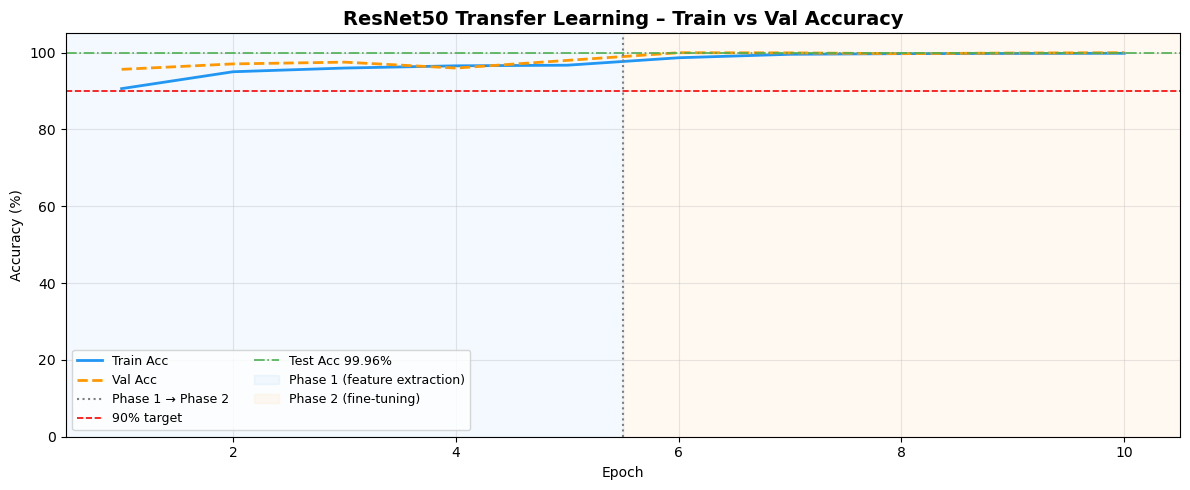

📊 Plot 16 saved → plot16_resnet50_accuracy.png


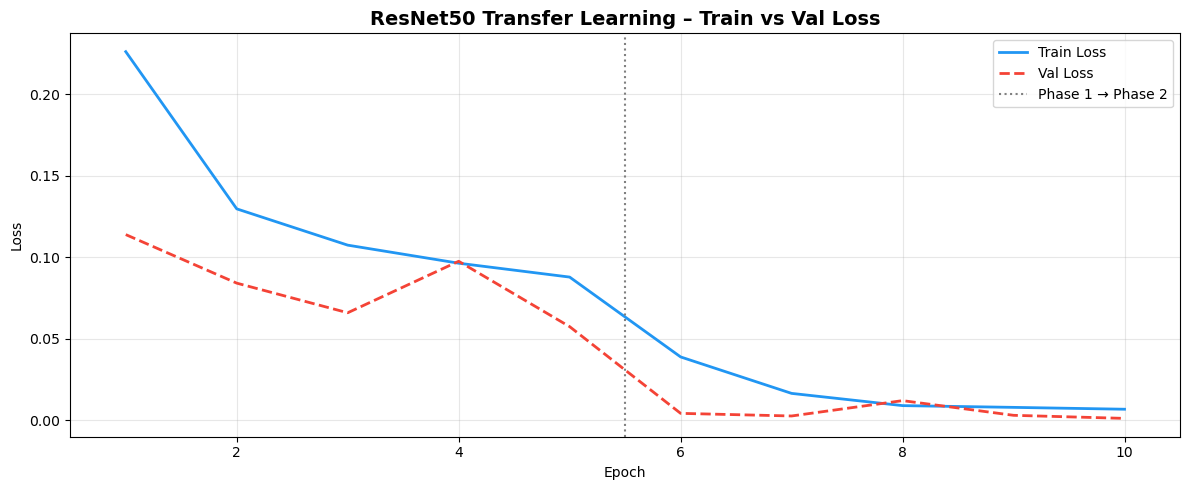

📊 Plot 17 saved → plot17_resnet50_loss.png


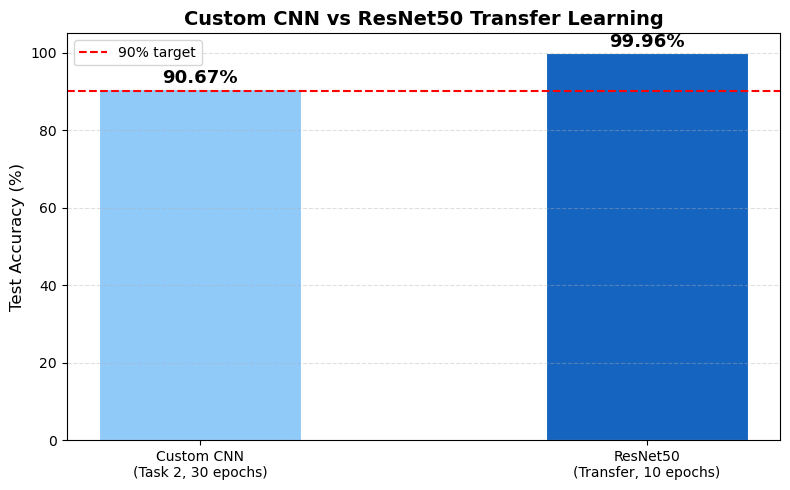

📊 Plot 18 saved → plot18_transfer_vs_custom.png


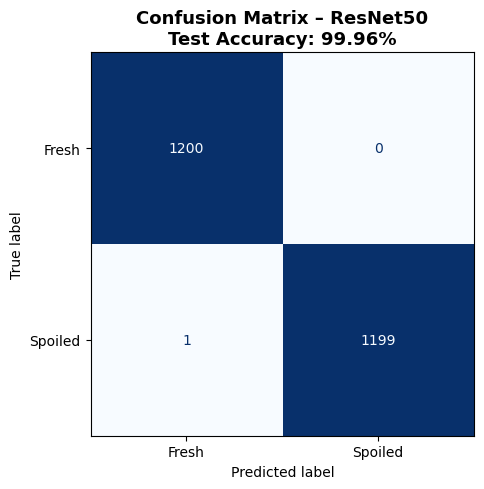

📊 Plot 19 saved → plot19_confusion_matrix.png


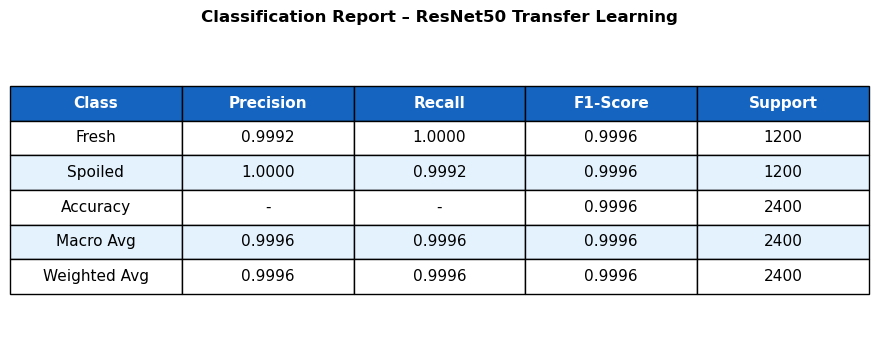

📊 Plot 20 saved → plot20_classification_report.png


In [11]:
# ─────────────────────────────────────────────
# 10. VISUALISATIONS
# ─────────────────────────────────────────────
 
# ── Merge phase histories for plotting ────────────────────────
combined_train_acc  = history_p1["train_acc"]  + history_p2["train_acc"]
combined_val_acc    = history_p1["val_acc"]     + history_p2["val_acc"]
combined_train_loss = history_p1["train_loss"]  + history_p2["train_loss"]
combined_val_loss   = history_p1["val_loss"]    + history_p2["val_loss"]
total_epochs        = len(combined_train_acc)
phase1_end          = len(history_p1["train_acc"])
 
 
# ── Plot 1: Accuracy curve (both phases) ──────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
eps = range(1, total_epochs + 1)
 
ax.plot(eps, combined_train_acc, label="Train Acc",
        color="#2196F3", linewidth=2)
ax.plot(eps, combined_val_acc,   label="Val Acc",
        color="#FF9800", linewidth=2, linestyle="--")
ax.axvline(phase1_end + 0.5, color="grey", linestyle=":",
           linewidth=1.5, label="Phase 1 → Phase 2")
ax.axhline(90, color="red", linestyle="--", linewidth=1.2,
           label="90% target")
ax.axhline(ts_acc, color="#4CAF50", linestyle="-.", linewidth=1.2,
           label=f"Test Acc {ts_acc:.2f}%")
 
ax.fill_between([0.5, phase1_end + 0.5],
                0, 105, alpha=0.05, color="#2196F3",
                label="Phase 1 (feature extraction)")
ax.fill_between([phase1_end + 0.5, total_epochs + 0.5],
                0, 105, alpha=0.05, color="#FF9800",
                label="Phase 2 (fine-tuning)")
 
ax.set_title("ResNet50 Transfer Learning – Train vs Val Accuracy",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105); ax.set_xlim(0.5, total_epochs + 0.5)
ax.legend(fontsize=9, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot16_resnet50_accuracy.png", dpi=150)
plt.show()
print("📊 Plot 16 saved → plot16_resnet50_accuracy.png")
 
 
# ── Plot 2: Loss curve (both phases) ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eps, combined_train_loss, label="Train Loss",
        color="#2196F3", linewidth=2)
ax.plot(eps, combined_val_loss,   label="Val Loss",
        color="#F44336", linewidth=2, linestyle="--")
ax.axvline(phase1_end + 0.5, color="grey", linestyle=":",
           linewidth=1.5, label="Phase 1 → Phase 2")
ax.set_title("ResNet50 Transfer Learning – Train vs Val Loss",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_xlim(0.5, total_epochs + 0.5)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot17_resnet50_loss.png", dpi=150)
plt.show()
print("📊 Plot 17 saved → plot17_resnet50_loss.png")
 
 
# ── Plot 3: Transfer vs Custom CNN comparison ─────────────────
categories  = ["Custom CNN\n(Task 2, 30 epochs)",
               "ResNet50\n(Transfer, 10 epochs)"]
test_scores = [90.67, ts_acc]
bar_colors  = ["#90CAF9", "#1565C0"]
 
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(categories, test_scores, color=bar_colors,
              edgecolor="white", linewidth=0.8, width=0.45)
ax.axhline(90, color="red", linestyle="--",
           linewidth=1.5, label="90% target")
for bar, acc in zip(bars, test_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f"{acc:.2f}%", ha="center", va="bottom",
            fontsize=13, fontweight="bold")
ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_ylim(0, 105)
ax.set_title("Custom CNN vs ResNet50 Transfer Learning",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("plot18_transfer_vs_custom.png", dpi=150)
plt.show()
print("📊 Plot 18 saved → plot18_transfer_vs_custom.png")
 
 
# ── Plot 4: Confusion Matrix ──────────────────────────────────
cm   = confusion_matrix(ts_labels, ts_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=BINARY_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix – ResNet50\nTest Accuracy: {ts_acc:.2f}%",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot19_confusion_matrix.png", dpi=150)
plt.show()
print("📊 Plot 19 saved → plot19_confusion_matrix.png")
 
 
# ── Plot 5: Classification Report ─────────────────────────────
report = classification_report(
    ts_labels, ts_preds,
    target_names=BINARY_NAMES, output_dict=True
)
rows = []
for cls in BINARY_NAMES + ["accuracy", "macro avg", "weighted avg"]:
    if cls == "accuracy":
        rows.append(["Accuracy", "-", "-",
                     f"{report[cls]:.4f}",
                     int(report["macro avg"]["support"])])
    else:
        rows.append([
            cls.title(),
            f"{report[cls]['precision']:.4f}",
            f"{report[cls]['recall']:.4f}",
            f"{report[cls]['f1-score']:.4f}",
            int(report[cls]["support"]),
        ])
 
col_labels = ["Class", "Precision", "Recall", "F1-Score", "Support"]
fig, ax    = plt.subplots(figsize=(9, 3.5))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=col_labels,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.3, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1565C0")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#E3F2FD")
ax.set_title("Classification Report – ResNet50 Transfer Learning",
             fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("plot20_classification_report.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("📊 Plot 20 saved → plot20_classification_report.png")

In [12]:
# ─────────────────────────────────────────────
# 11. FINAL SUMMARY
# ─────────────────────────────────────────────
 
print("\n" + "="*62)
print("     FRESHHARVEST – WEEK 2 TASK 1 SUMMARY")
print("="*62)
print(f"  Architecture    : ResNet50 (pretrained ImageNet)")
print(f"  Custom Head     : Linear(2048→256)→ReLU→Dropout→Linear(256→2)")
print(f"  Total Params    : {total_params:,}")
print(f"  Device          : {device}")
print("-"*62)
print(f"  Phase 1 (Feature Extraction)")
print(f"    Trainable     : FC head only ({trainable_phase1:,} params)")
print(f"    LR            : {PHASE1_LR}")
print(f"    Epochs run    : {stopped_p1}/{PHASE1_EPOCHS}")
print(f"    Best Val Acc  : {best_val_p1:.2f}%")
print(f"  Phase 2 (Fine-tuning layer4 + FC)")
print(f"    Trainable     : layer4 + FC ({trainable_phase2:,} params)")
print(f"    LR            : {PHASE2_LR}")
print(f"    Epochs run    : {stopped_p2}/{PHASE2_EPOCHS}")
print(f"    Best Val Acc  : {best_val_p2:.2f}%")
print("-"*62)
print(f"  Custom CNN Test Acc  : 90.67%  (30 epochs)")
target = "✅ TARGET MET!" if ts_acc >= 90 else "⚠️  Below 90%"
print(f"  ResNet50 Test Acc    : {ts_acc:.2f}%  "
      f"(10 epochs total)  {target}")
print(f"\n  💾 Saved → freshharvest_resnet50.pt")
print("="*62)
print("\n✅ Week 2 Task 1 complete – Transfer Learning done!\n")
 
# ── How to reload the model later ─────────────────────────────
print("─"*62)
print("  📌 To reload this model later:")
print("─"*62)
print("""
  from torchvision import models
  import torch.nn as nn
 
  checkpoint = torch.load('freshharvest_resnet50.pt',
                           weights_only=False)
 
  model = models.resnet50(weights=None)
  model.fc = nn.Sequential(
      nn.Linear(2048, 256),
      nn.ReLU(inplace=True),
      nn.Dropout(p=0.4),
      nn.Linear(256, 2),
  )
  model.load_state_dict(checkpoint['model_state'])
  model.eval()
  print(f"Loaded! Test Acc was: {checkpoint['test_acc']:.2f}%")
""")


     FRESHHARVEST – WEEK 2 TASK 1 SUMMARY
  Architecture    : ResNet50 (pretrained ImageNet)
  Custom Head     : Linear(2048→256)→ReLU→Dropout→Linear(256→2)
  Total Params    : 24,033,090
  Device          : cuda
--------------------------------------------------------------
  Phase 1 (Feature Extraction)
    Trainable     : FC head only (525,058 params)
    LR            : 0.001
    Epochs run    : 5/5
    Best Val Acc  : 97.96%
  Phase 2 (Fine-tuning layer4 + FC)
    Trainable     : layer4 + FC (15,489,794 params)
    LR            : 0.0001
    Epochs run    : 5/5
    Best Val Acc  : 99.96%
--------------------------------------------------------------
  Custom CNN Test Acc  : 90.67%  (30 epochs)
  ResNet50 Test Acc    : 99.96%  (10 epochs total)  ✅ TARGET MET!

  💾 Saved → freshharvest_resnet50.pt

✅ Week 2 Task 1 complete – Transfer Learning done!

──────────────────────────────────────────────────────────────
  📌 To reload this model later:
───────────────────────────────────────